# TTN interval 各 band 疾病分布

使用 `HGMD_TTN_processed (1).xlsx` 的資料，依 TTN (chr2, 負股) 的**結構分區 (band)** 將變異分組，並繪製每個 band 上各疾病類型 (`phenotype`: cardiac / skeletal / both / unsure) 的分布情形。

TTN 基因座標範圍：**178,525,989 – 178,807,423**。各 band 定義（基因組座標，由 N 端 Z-disk 到 C 端 M-band）：

| band | 基因組座標 (chr2) | 長度 (bp) |
|---|---|---|
| Z-disk | 178,775,356 – 178,807,423 | 32,067 |
| I-band | 178,618,584 – 178,775,356 | 156,772 |
| A-band | 178,535,982 – 178,618,584 | 82,602 |
| M-band | 178,525,989 – 178,535,982 | 9,993 |

（TTN 位於負股，故 Z-disk 對應較大的基因組座標。）

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 設定支援中文的字型 (Noto Sans CJK)
mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Droid Sans Fallback', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False

FILE = 'HGMD_TTN_processed (1).xlsx'
df = pd.read_excel(FILE)
print('shape:', df.shape)
df[['#CHROM', 'POS', 'GENE', 'PHEN', 'phenotype']].head()

shape: (1094, 24)


,#CHROM,POS,GENE,PHEN,phenotype
0,2,178527031,TTN,Skeletal myopathy,skeletal
1,2,178527098,TTN,Tibial muscular dystrophy,skeletal
2,2,178527121,TTN,Tibial muscular dystrophy,skeletal
3,2,178527148,TTN,Tibial muscular dystrophy,skeletal
4,2,178527148,TTN,Cardiomyopathy; dilated,cardiac


## 1. 定義 TTN 結構 band 並標記每個變異

依基因組座標 `POS` 把每個變異對應到所屬的結構 band。band 順序由 N 端 (Z-disk) 至 C 端 (M-band)。

In [19]:
TTN_START, TTN_END = 178525989, 178807423

# (band 名稱, 起點, 終點)  —— 起點 < 終點
band_defs = [
    ('M-band', 178525989, 178535982),
    ('A-band', 178535982, 178618584),
    ('I-band', 178618584, 178775356),
    ('Z-disk', 178775356, 178807423),
]

# 繪圖呈現順序：N 端 -> C 端
band_order = ['Z-disk', 'I-band', 'A-band', 'M-band']

edges = [b[1] for b in band_defs] + [band_defs[-1][2]]
labels_asc = [b[0] for b in band_defs]
df['band'] = pd.cut(df['POS'], bins=edges, labels=labels_asc, include_lowest=True)

# 檢查是否有變異落在定義範圍外
n_out = df['band'].isna().sum()
print(f'落在 band 範圍外的變異數: {n_out}')
print(f'POS 範圍: {df["POS"].min():,} – {df["POS"].max():,}')
df[['POS', 'band', 'phenotype']].head()

落在 band 範圍外的變異數: 0
POS 範圍: 178,527,031 – 178,802,316


,POS,band,phenotype
0,178527031,M-band,skeletal
1,178527098,M-band,skeletal
2,178527121,M-band,skeletal
3,178527148,M-band,skeletal
4,178527148,M-band,cardiac


## 2. 統計各 band 的疾病分布

統計每個 band 內各 phenotype 的變異數量。

In [20]:
pheno_order = ['cardiac', 'skeletal', 'both', 'others']
colors = {'cardiac': '#d62728', 'skeletal': '#1f77b4', 'both': '#9467bd', 'others': '#7f7f7f'}

counts = (df.groupby(['band', 'phenotype'], observed=False)
            .size()
            .unstack('phenotype')
            .reindex(index=band_order, columns=pheno_order)
            .fillna(0)
            .astype(int))
counts['total'] = counts.sum(axis=1)
counts

phenotype,cardiac,skeletal,both,others,total
band,,,,,
Z-disk,38,18,0,0,56
I-band,193,127,11,0,331
A-band,468,137,7,0,612
M-band,44,40,2,0,86


## 3. 各 band 疾病分布（堆疊長條圖：數量）

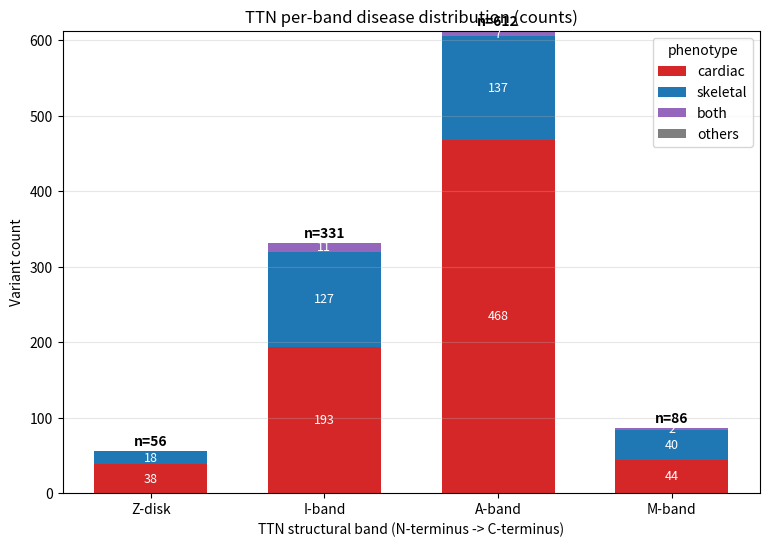

In [21]:
x = np.arange(len(band_order))
fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(len(band_order))
for ph in pheno_order:
    vals = counts.loc[band_order, ph].values
    bars = ax.bar(x, vals, bottom=bottom, label=ph, color=colors[ph], width=0.65)
    # 在每個 segment 標數量
    for xi, v, b in zip(x, vals, bottom):
        if v > 0:
            ax.text(xi, b + v / 2, int(v), ha='center', va='center', fontsize=9, color='white')
    bottom += vals

# 總數標在柱頂
for xi, t in zip(x, counts.loc[band_order, 'total'].values):
    ax.text(xi, t + 3, f'n={t}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(band_order)
ax.set_xlabel('TTN structural band (N-terminus -> C-terminus)')
ax.set_ylabel('Variant count')
ax.set_title('TTN per-band disease distribution (counts)')
ax.legend(title='phenotype')
ax.grid(axis='y', alpha=0.3)
ax.margins(y=0.1)
# plt.tight_layout()
# plt.show()

## 4. 各 band 疾病組成比例（100% 堆疊圖）

以比例呈現每個 band 內疾病類型的相對占比，柱頂標示該 band 的變異總數。

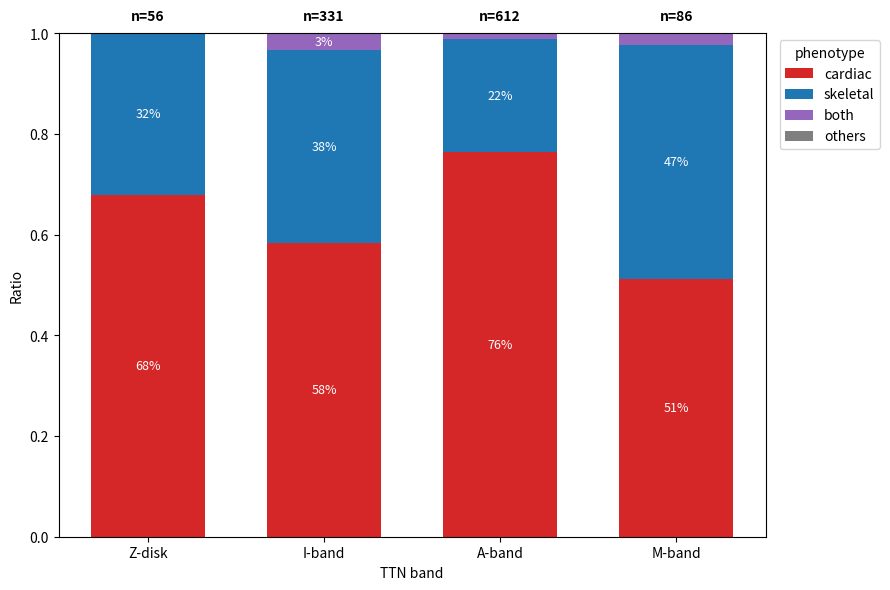

In [22]:
prop = counts.loc[band_order, pheno_order].div(counts.loc[band_order, 'total'], axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(len(band_order))
for ph in pheno_order:
    vals = prop[ph].values
    ax.bar(x, vals, bottom=bottom, label=ph, color=colors[ph], width=0.65)
    for xi, v, b in zip(x, vals, bottom):
        if v > 0.03:
            ax.text(xi, b + v / 2, f'{v*100:.0f}%', ha='center', va='center', fontsize=9, color='white')
    bottom += vals

for xi, t in zip(x, counts.loc[band_order, 'total'].values):
    ax.text(xi, 1.02, f'n={t}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(band_order)
ax.set_xlabel('TTN band')
ax.set_ylabel('Ratio')
ax.set_ylim(0, 1)
ax.legend(title='phenotype', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. 沿 TTN 基因座標的逐位點變異分布

以 TTN 基因座標範圍（**178,525,989 – 178,807,423**，共 **281,435** 個位點）為橫軸，在每個有變異的位點畫一根 bar，bar 的高度等於該位點的變異數（變異越多越高）。依 ground truth `phenotype` 分成 **cardiac / skeletal / both** 三張圖，藉此呈現心臟與骨骼肌變異沿基因的分布情形。

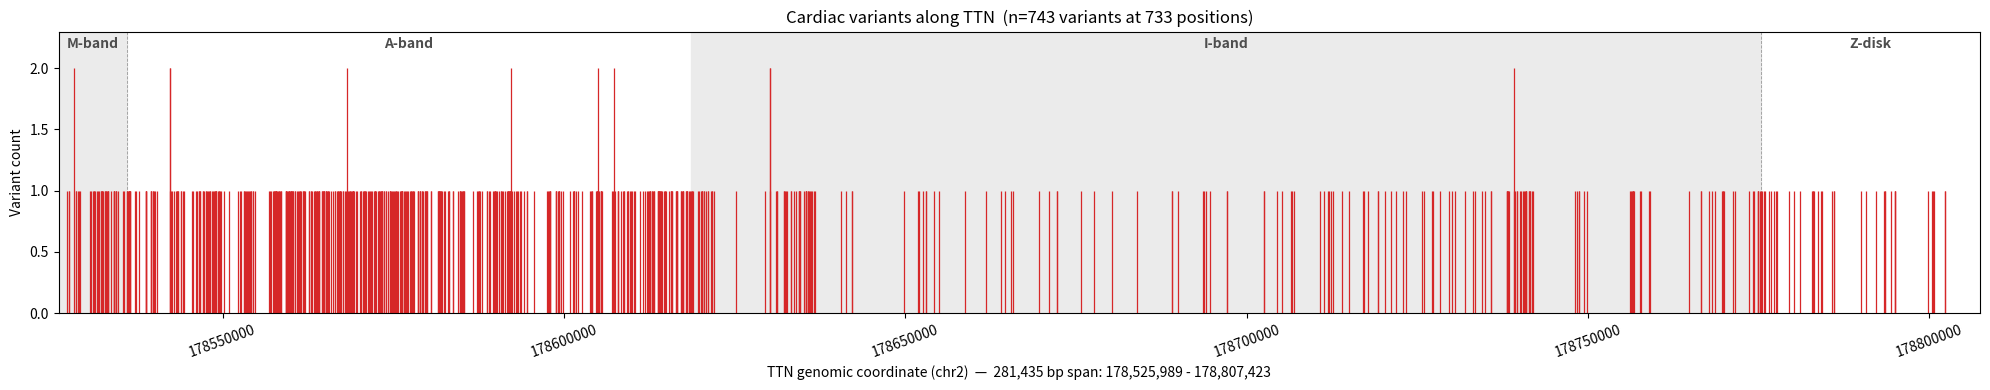

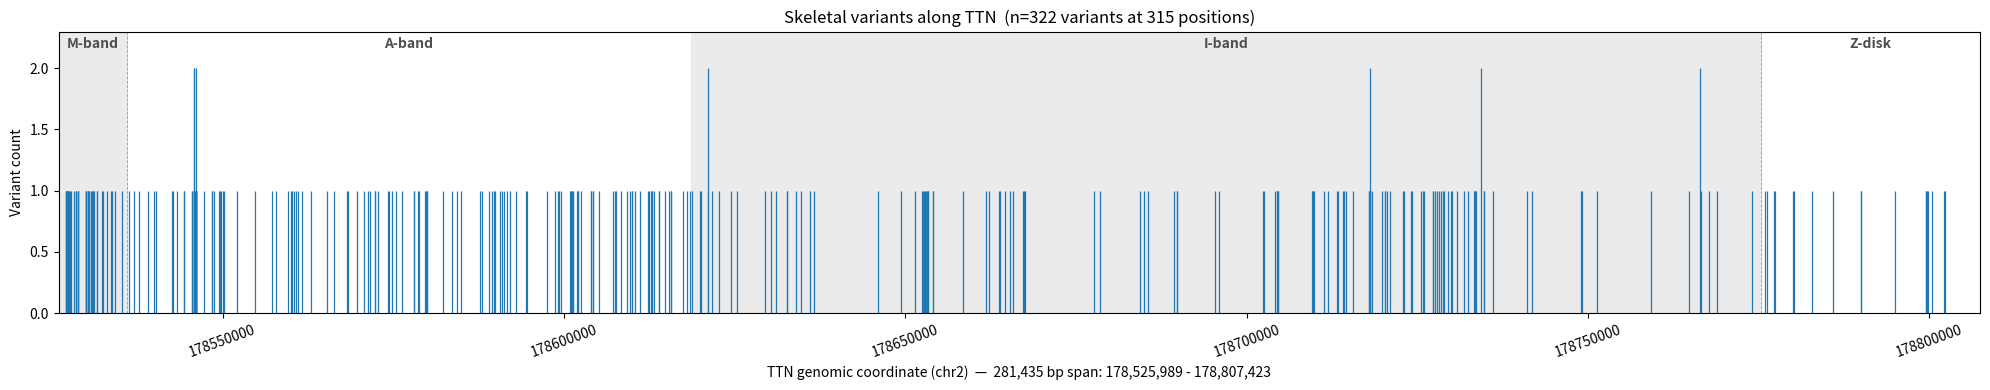

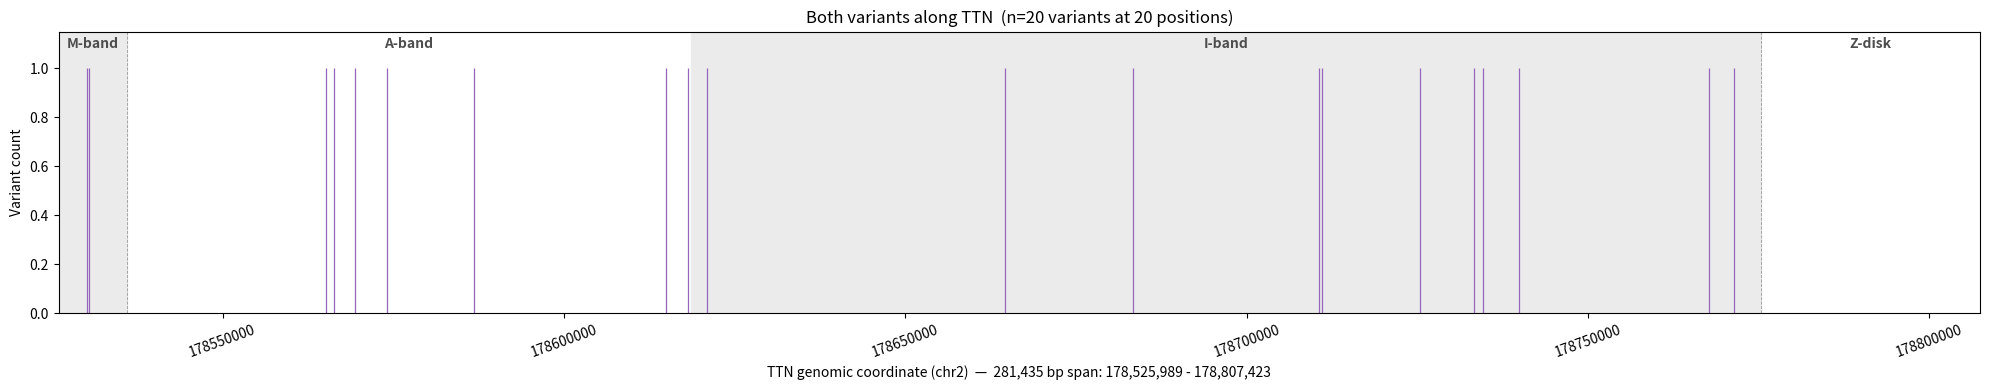

In [23]:
# 逐位點 bar 圖：x 軸為 TTN 基因座標範圍 (281,435 個點)，bar 高 = 該位點變異數
GENE_START, GENE_END = 178525989, 178807423
n_points = GENE_END - GENE_START + 1  # 281,435
positions = np.arange(GENE_START, GENE_END + 1)

# band 邊界與名稱 (基因組座標；TTN 位於負股，Z-disk 在較大座標)
band_bounds = [
    ('M-band', 178525989, 178535982),
    ('A-band', 178535982, 178618584),
    ('I-band', 178618584, 178775356),
    ('Z-disk', 178775356, 178807423),
]

targets = ['cardiac', 'skeletal', 'both']

for ph in targets:
    height = np.zeros(n_points, dtype=int)
    vc = df.loc[df['phenotype'] == ph, 'POS'].value_counts()
    idx = vc.index.to_numpy() - GENE_START
    valid = (idx >= 0) & (idx < n_points)
    height[idx[valid]] = vc.to_numpy()[valid]

    fig, ax = plt.subplots(figsize=(20, 4))

    # band 分區背景 (交錯灰底) 與邊界虛線
    for i, (name, s, e) in enumerate(band_bounds):
        if i % 2 == 0:
            ax.axvspan(s, e, color='0.92', zorder=0)
        ax.axvline(e, color='0.6', linestyle='--', linewidth=0.6, zorder=0)

    nz = height > 0
    ax.vlines(positions[nz], 0, height[nz], color=colors[ph], linewidth=0.9, zorder=2)

    ax.set_xlim(GENE_START, GENE_END)
    ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:.0f}'))
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(6))
    ax.tick_params(axis='x', rotation=20)
    ymax = max(int(height.max()), 1) * 1.15
    ax.set_ylim(0, ymax)
    ax.set_ylabel('Variant count')
    ax.set_xlabel(f'TTN genomic coordinate (chr2)  —  '
                  f'{n_points:,} bp span: {GENE_START:,} - {GENE_END:,}')
    ax.set_title(f'{ph.capitalize()} variants along TTN  '
                 f'(n={int(height.sum())} variants at {int(nz.sum())} positions)')

    # band 名稱標在圖頂
    for name, s, e in band_bounds:
        ax.text((s + e) / 2, ymax * 0.98, name, ha='center', va='top',
                fontsize=10, fontweight='bold', color='0.3')

    plt.tight_layout()
    plt.show()

## 6. 更易讀的變異分布圖

逐位點圖太細碎，改用兩種較好讀的呈現：

1. **分箱密度圖 (5 kb bins)**：把座標每 5 kb 分成一個 bin，計算每個 bin 內各 phenotype 的變異數，用重疊折線／半透明面積比較 cardiac / skeletal / both 沿基因的分布與熱區。
2. **各 band 變異密度 (variants per kb)**：因為四個 band 長度差異很大（I-band ~157 kb vs M-band ~10 kb），改用「每 kb 變異數」而非原始 count，公平比較各結構區的變異偏好。

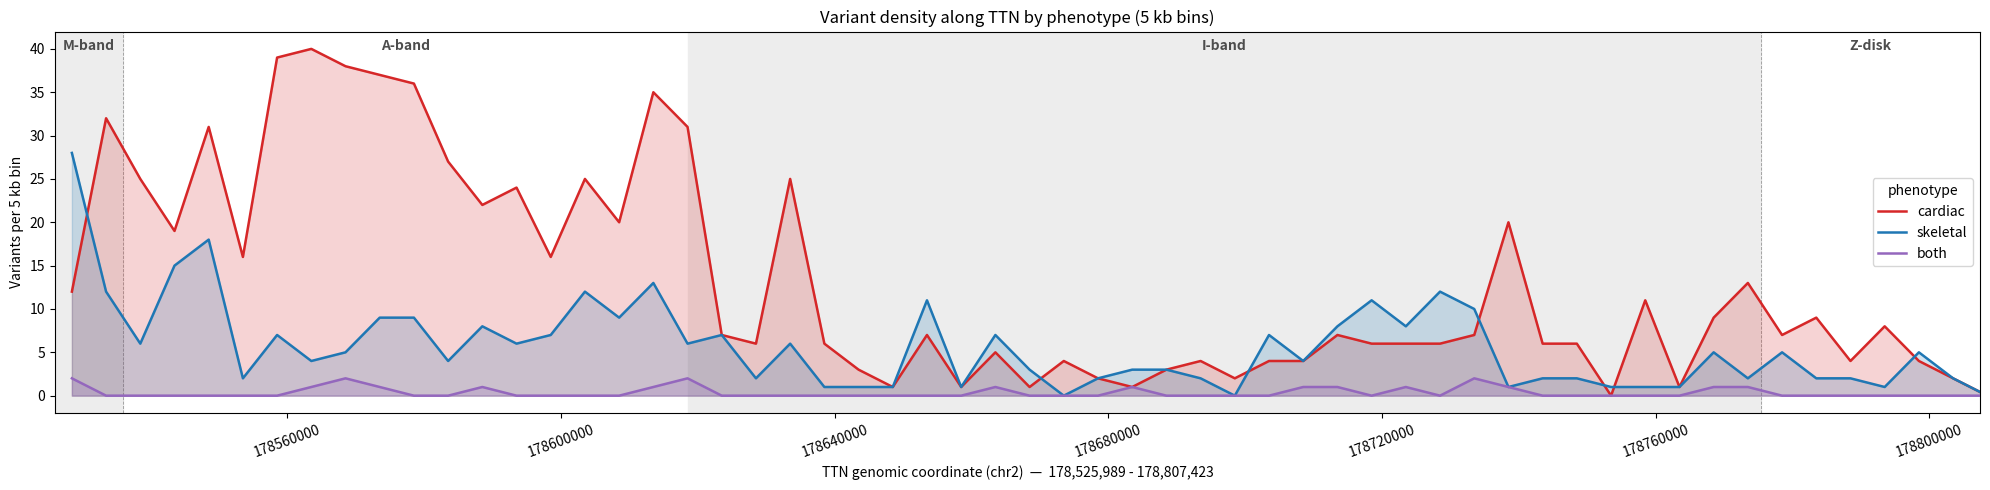

In [24]:
# 分箱密度圖：每 5 kb 一個 bin，重疊比較三個 phenotype
bin_size = 5000
bin_edges = np.arange(GENE_START, GENE_END + bin_size, bin_size)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, ax = plt.subplots(figsize=(20, 5))

# band 分區背景 (交錯灰底) 與邊界虛線
for i, (name, s, e) in enumerate(band_bounds):
    if i % 2 == 0:
        ax.axvspan(s, e, color='0.93', zorder=0)
    ax.axvline(e, color='0.6', linestyle='--', linewidth=0.6, zorder=0)

for ph in ['cardiac', 'skeletal', 'both']:
    pos = df.loc[df['phenotype'] == ph, 'POS'].to_numpy()
    h, _ = np.histogram(pos, bins=bin_edges)
    ax.plot(centers, h, label=ph, color=colors[ph], linewidth=1.8, zorder=3)
    ax.fill_between(centers, h, color=colors[ph], alpha=0.20, zorder=2)

ax.set_xlim(GENE_START, GENE_END)
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:.0f}'))
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(8))
ax.tick_params(axis='x', rotation=20)
ymax = ax.get_ylim()[1]
for name, s, e in band_bounds:
    ax.text((s + e) / 2, ymax * 0.98, name, ha='center', va='top',
            fontsize=10, fontweight='bold', color='0.3')

ax.set_xlabel(f'TTN genomic coordinate (chr2)  —  {GENE_START:,} - {GENE_END:,}')
ax.set_ylabel(f'Variants per {bin_size // 1000} kb bin')
ax.set_title('Variant density along TTN by phenotype (5 kb bins)')
ax.legend(title='phenotype')
plt.tight_layout()
plt.show()

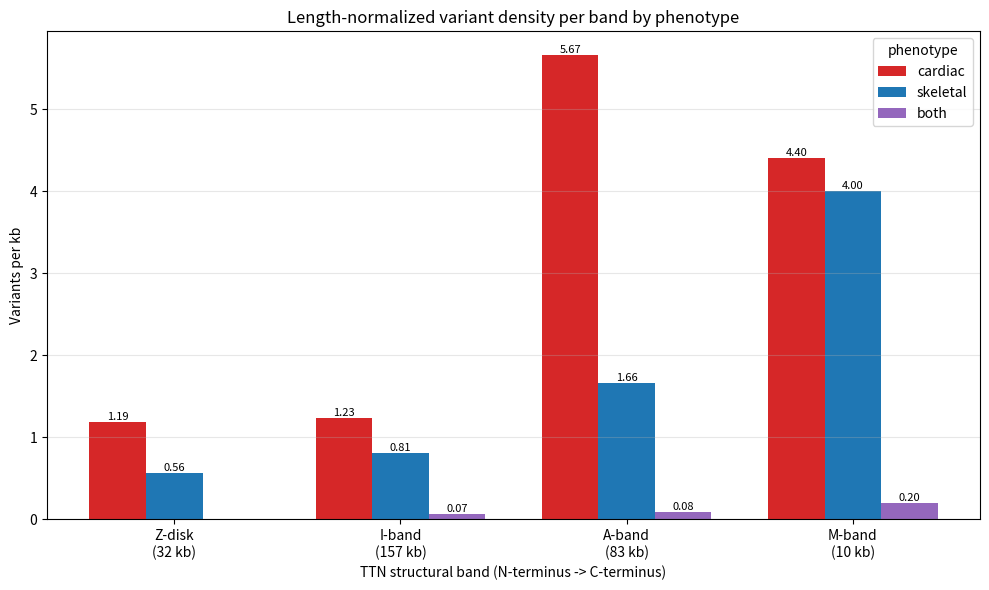

In [25]:
# 各 band 變異密度 (variants per kb)：以 band 長度標準化，公平比較結構區偏好
band_len_kb = pd.Series({name: (e - s) / 1000 for name, s, e in band_bounds})
phenos = ['cardiac', 'skeletal', 'both']

# counts 來自前面 Section 2（band x phenotype 的原始數量）
density = counts.loc[band_order, phenos].div(band_len_kb.reindex(band_order), axis=0)

x = np.arange(len(band_order))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
for i, ph in enumerate(phenos):
    offset = (i - (len(phenos) - 1) / 2) * width
    bars = ax.bar(x + offset, density.loc[band_order, ph].values, width,
                  label=ph, color=colors[ph])
    for xi, v in zip(x + offset, density.loc[band_order, ph].values):
        if v > 0:
            ax.text(xi, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'{b}\n({band_len_kb[b]:.0f} kb)' for b in band_order])
ax.set_xlabel('TTN structural band (N-terminus -> C-terminus)')
ax.set_ylabel('Variants per kb')
ax.set_title('Length-normalized variant density per band by phenotype')
ax.legend(title='phenotype')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 心臟／骨骼肌變異在各 transcript isoform 上的分布

使用 `transcript_interval.xlsx`（7 種 TTN isoform：Meta / N2BA / N2B / N2A / Nvx1–3）的涵蓋區間，依每個變異的 `POS` 判斷它落在哪些 isoform 的涵蓋範圍內（一個變異可能同時屬於多個 isoform），再統計各 isoform 上 cardiac / skeletal / both 變異的分布。由於不同 isoform 涵蓋不同區段（尤其 I-band 可變剪接區），落在其上的變異組成也會不同。

1. **各 isoform 上的變異數**（分組長條圖）：比較每個 isoform 涵蓋到多少 cardiac / skeletal / both 變異。
2. **各 isoform 變異的 phenotype 組成比例**（100% 堆疊圖）：看每個 isoform 的變異以哪種 phenotype 為主。

      cardiac  skeletal  both  total
Meta      737       319    20   1076
N2BA      713       298    19   1030
N2B       654       224    13    891
N2A       692       296    18   1006
Nvx1      657       224    13    894
Nvx2      661       224    13    898
Nvx3       64        29     2     95


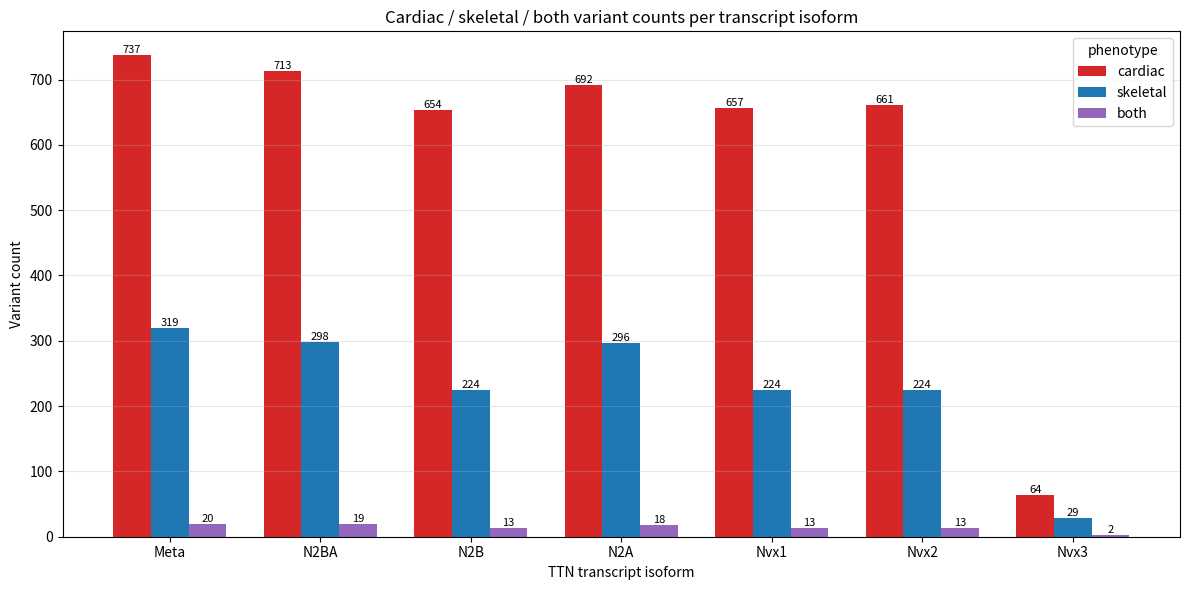

In [26]:
# 讀取 transcript isoform 區間並解析成 (lo, hi) list
tx_df = pd.read_excel('transcript_interval.xlsx')
interval_cols = [c for c in tx_df.columns if c.startswith('interval')]


def parse_intervals(row):
    ivs = []
    for c in interval_cols:
        v = row[c]
        if pd.isna(v):
            continue
        a, b = str(v).split('-')
        lo, hi = sorted((int(a), int(b)))
        ivs.append((lo, hi))
    return sorted(ivs)


transcripts = tx_df['transcript'].tolist()
tx_intervals = {row['transcript']: parse_intervals(row) for _, row in tx_df.iterrows()}

# 依 POS 判斷每個變異落在哪些 isoform 涵蓋區間內，統計各 isoform 上各 phenotype 變異數
phenos = ['cardiac', 'skeletal', 'both']
pos_arr = df['POS'].to_numpy()
ph_arr = df['phenotype'].to_numpy()


def pos_on_transcript(pos, intervals):
    m = np.zeros(len(pos), dtype=bool)
    for lo, hi in intervals:
        m |= (pos >= lo) & (pos <= hi)
    return m


tx_counts = pd.DataFrame(
    {tx: {ph: int(((ph_arr == ph) & pos_on_transcript(pos_arr, tx_intervals[tx])).sum())
          for ph in phenos}
     for tx in transcripts}
).T[phenos]
tx_counts['total'] = tx_counts.sum(axis=1)
print(tx_counts)

# 分組長條圖：各 isoform 上的變異數（依 phenotype）
x = np.arange(len(transcripts))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
for i, ph in enumerate(phenos):
    offset = (i - (len(phenos) - 1) / 2) * width
    ax.bar(x + offset, tx_counts.loc[transcripts, ph].values, width, label=ph, color=colors[ph])
    for xi, v in zip(x + offset, tx_counts.loc[transcripts, ph].values):
        if v > 0:
            ax.text(xi, v, str(int(v)), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(transcripts)
ax.set_xlabel('TTN transcript isoform')
ax.set_ylabel('Variant count')
ax.set_title('Cardiac / skeletal / both variant counts per transcript isoform')
ax.legend(title='phenotype')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

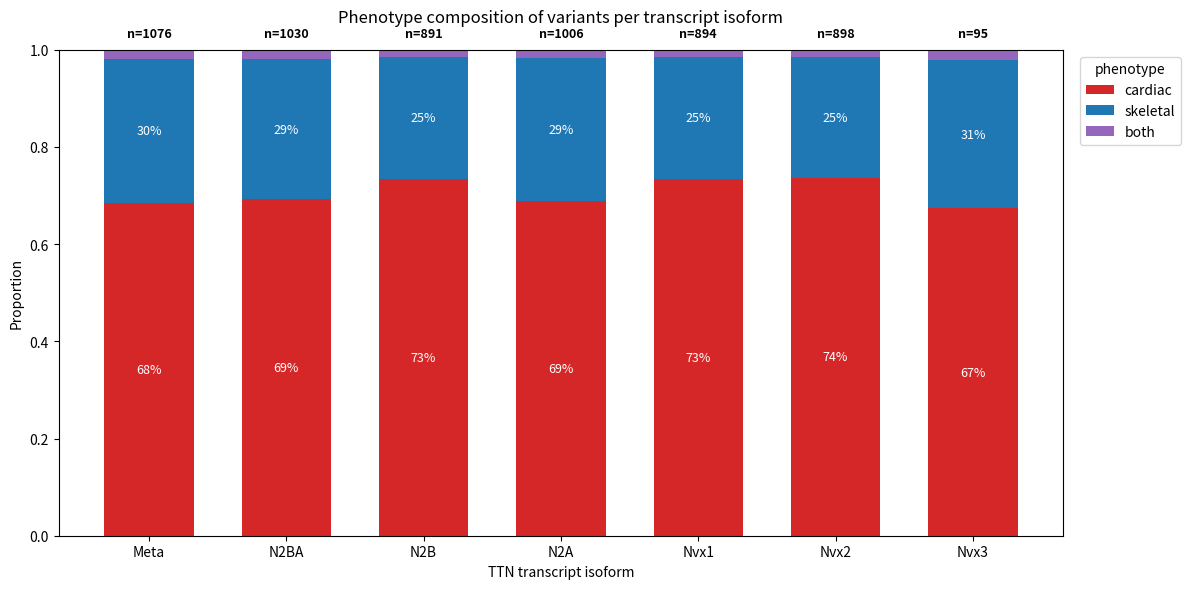

In [27]:
# 100% 堆疊圖：各 isoform 上變異的 phenotype 組成比例
comp = tx_counts[phenos].div(tx_counts[phenos].sum(axis=1).clip(lower=1), axis=0)

x = np.arange(len(transcripts))
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(transcripts))
for ph in phenos:
    vals = comp.loc[transcripts, ph].values
    ax.bar(x, vals, bottom=bottom, label=ph, color=colors[ph], width=0.65)
    for xi, v, b in zip(x, vals, bottom):
        if v > 0.03:
            ax.text(xi, b + v / 2, f'{v*100:.0f}%', ha='center', va='center', fontsize=9, color='white')
    bottom += vals

for xi, t in zip(x, tx_counts.loc[transcripts, 'total'].values):
    ax.text(xi, 1.02, f'n={int(t)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(transcripts)
ax.set_ylim(0, 1)
ax.set_xlabel('TTN transcript isoform')
ax.set_ylabel('Proportion')
ax.set_title('Phenotype composition of variants per transcript isoform', pad=20)
ax.legend(title='phenotype', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 7.3 變異位置對齊 transcript 結構（逐位點 + 分箱密度）

把三個面板對齊在同一條 TTN 基因座標軸上，方便看出心臟／骨骼肌變異落在各 isoform 的哪些區段：

1. **上：分箱密度圖 (5 kb bins)** — cardiac / skeletal / both 沿座標的變異密度。
2. **中：逐位點變異分布** — 每個變異位置以 rug 標記（依 phenotype 分列）。
3. **下：transcript isoform 結構軌道** — 每個 isoform 涵蓋的區間。

三面板共用 x 軸，因此可直接對照：某段密度高峰／變異落點對應到哪些 isoform 有涵蓋。

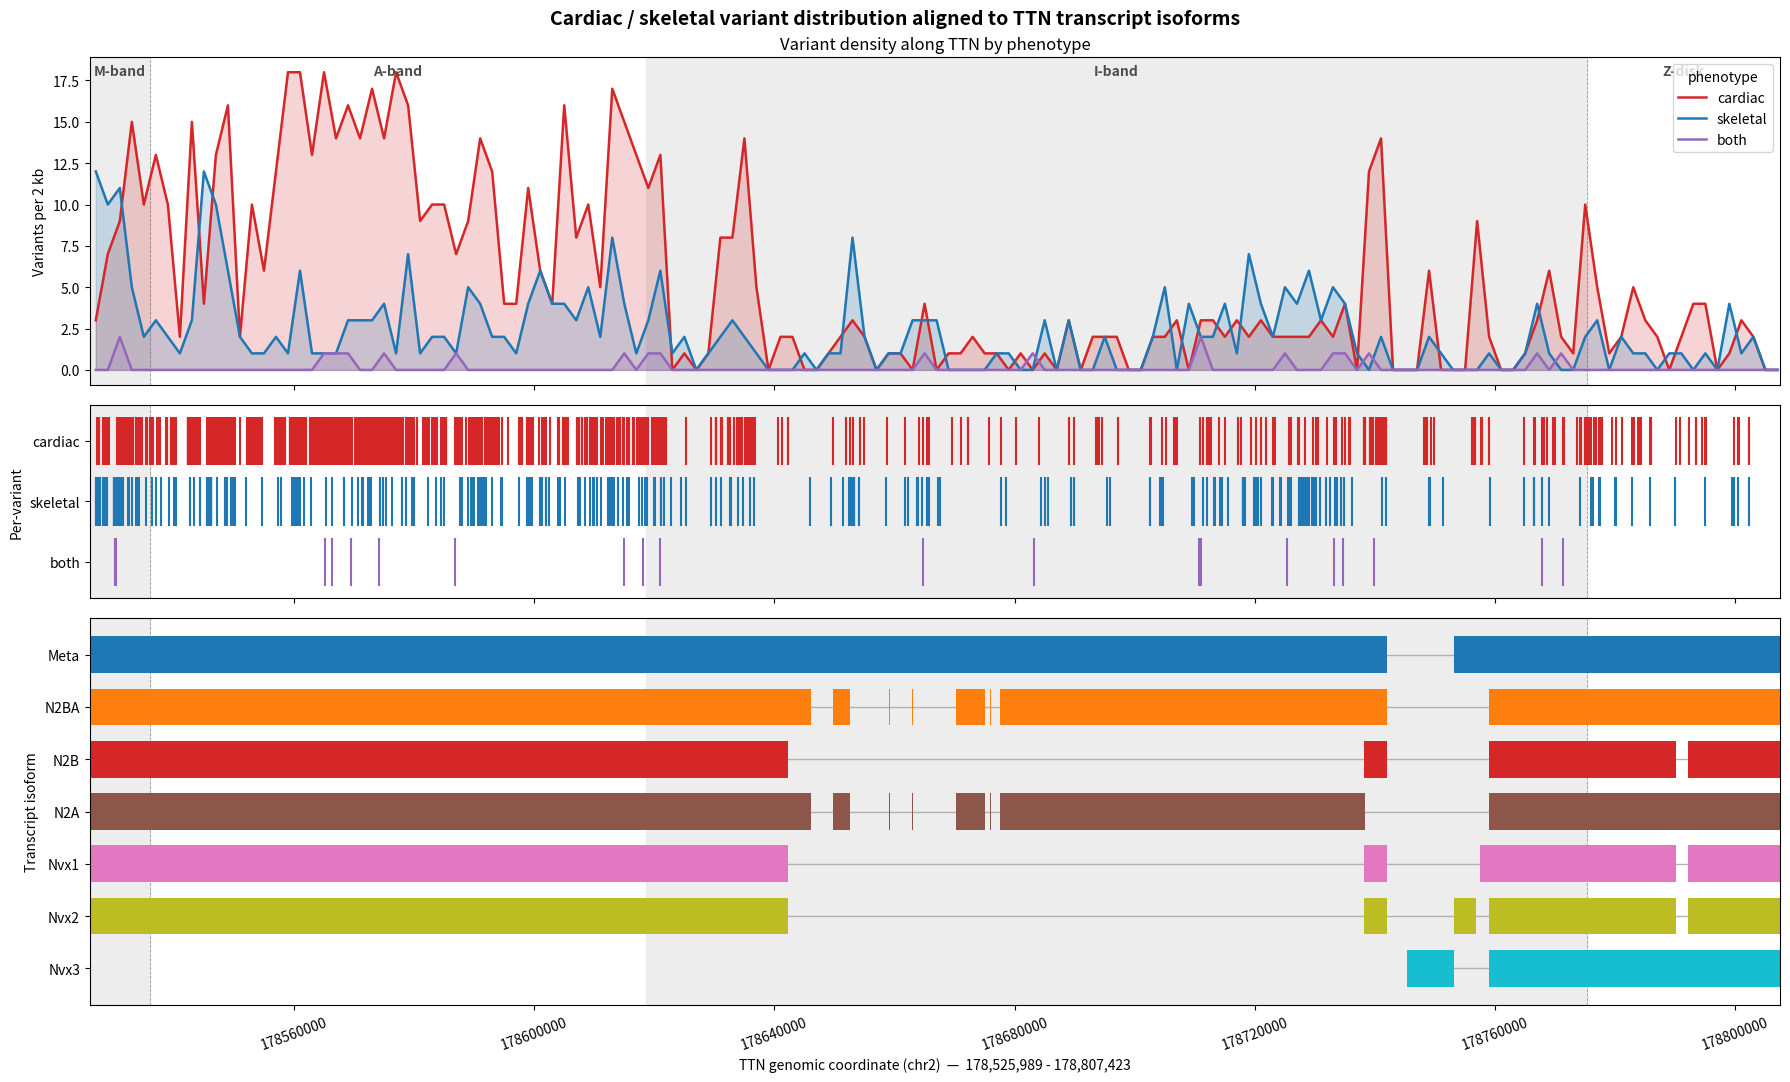

In [28]:
# Genome-browser 風格：分箱密度 + 逐位點 rug + transcript 結構，三面板共用 x 軸
fig, (ax_dens, ax_rug, ax_tx) = plt.subplots(
    3, 1, figsize=(18, 11), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.3, 2.6]})

# 各面板共同的 band 分區背景 (交錯灰底) 與邊界虛線
for ax in (ax_dens, ax_rug, ax_tx):
    for i, (name, s, e) in enumerate(band_bounds):
        if i % 2 == 0:
            ax.axvspan(s, e, color='0.93', zorder=0)
        ax.axvline(e, color='0.6', linestyle='--', linewidth=0.6, zorder=0)

# --- 上：分箱密度圖 (5 kb bins) ---
bin_size = 2000
bin_edges = np.arange(GENE_START, GENE_END + bin_size, bin_size)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2
for ph in phenos:
    pos = df.loc[df['phenotype'] == ph, 'POS'].to_numpy()
    h, _ = np.histogram(pos, bins=bin_edges)
    ax_dens.plot(centers, h, label=ph, color=colors[ph], linewidth=1.8, zorder=3)
    ax_dens.fill_between(centers, h, color=colors[ph], alpha=0.20, zorder=2)
ax_dens.set_ylabel(f'Variants per {bin_size // 1000} kb')
ax_dens.set_title('Variant density along TTN by phenotype')
ax_dens.legend(title='phenotype', loc='upper right')
ymax = ax_dens.get_ylim()[1]
for name, s, e in band_bounds:
    ax_dens.text((s + e) / 2, ymax * 0.98, name, ha='center', va='top',
                 fontsize=10, fontweight='bold', color='0.3')

# --- 中：逐位點變異分布 (rug，依 phenotype 分列) ---
offsets = list(range(len(phenos)))[::-1]  # cardiac 在最上列
ax_rug.eventplot([df.loc[df['phenotype'] == ph, 'POS'].to_numpy() for ph in phenos],
                 lineoffsets=offsets, linelengths=0.8,
                 colors=[colors[ph] for ph in phenos], zorder=3)
ax_rug.set_yticks(offsets)
ax_rug.set_yticklabels(phenos)
ax_rug.set_ylim(-0.6, len(phenos) - 0.4)
ax_rug.set_ylabel('Per-variant')

# --- 下：transcript isoform 結構軌道 ---
tx_colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(transcripts)))
for y, tx in enumerate(transcripts):
    ivs = tx_intervals[tx]
    if not ivs:
        continue
    ax_tx.hlines(y, min(lo for lo, _ in ivs), max(hi for _, hi in ivs),
                 color='0.7', linewidth=1, zorder=1)
    ax_tx.broken_barh([(lo, hi - lo) for lo, hi in ivs], (y - 0.35, 0.7),
                      facecolors=tx_colors[y], edgecolor='none', zorder=2)
ax_tx.set_yticks(range(len(transcripts)))
ax_tx.set_yticklabels(transcripts)
ax_tx.set_ylim(-0.7, len(transcripts) - 0.3)
ax_tx.invert_yaxis()
ax_tx.set_ylabel('Transcript isoform')

ax_tx.set_xlim(GENE_START, GENE_END)
ax_tx.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:.0f}'))
ax_tx.xaxis.set_major_locator(mpl.ticker.MaxNLocator(8))
ax_tx.tick_params(axis='x', rotation=20)
ax_tx.set_xlabel(f'TTN genomic coordinate (chr2)  —  {GENE_START:,} - {GENE_END:,}')
fig.suptitle('Cardiac / skeletal variant distribution aligned to TTN transcript isoforms',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()